# Código python: Matriz de confusión

In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

datos = pd.read_csv(
    "../20260515-viernes/telecom_churn.csv"
)

print("Dataset cargado correctamente.\n")

print("Primeros registros:\n")

display(datos.head())

# PREPROCESAMIENTO

encoder = LabelEncoder()

columnas = [
    "gender",
    "Contract",
    "InternetService"
]

for columna in columnas:

    datos[columna] = encoder.fit_transform(
        datos[columna]
    )

print("Variables categóricas transformadas.\n")

# VARIABLES PREDICTORAS Y OBJETIVO

X = datos[
    [
        "gender",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "InternetService"
    ]
]

y = datos["Churn"]

print("Variables predictoras seleccionadas.\n")

print("Variable objetivo: Churn")

# DIVISIÓN DE DATOS

print("\n================================================")

print("DIVISIÓN DE DATOS")

print("================================================\n")

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

print("Datos de entrenamiento y prueba creados.\n")

print(f"Registros de entrenamiento: {len(X_train)}")

print(f"Registros de prueba: {len(X_test)}")

# CREACIÓN DEL MODELO

print("\n================================================")

print("ENTRENAMIENTO DEL MODELO")

print("================================================\n")

modelo = RandomForestClassifier(

    n_estimators=100,
    random_state=42

)

modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

# PREDICCIONES

print("\n================================================")

print("REALIZANDO PREDICCIONES")

print("================================================\n")

predicciones = modelo.predict(X_test)

print("Primeras predicciones:\n")

print(predicciones[:10])

# MATRIZ DE CONFUSIÓN

print("================ MATRIZ DE CONFUSIÓN ============\n")

matriz = confusion_matrix(
    y_test,
    predicciones
)

print(matriz)

# OBTENER VN, FP, FN, VP

VN, FP, FN, VP = matriz.ravel()

# MOSTRAR RESULTADOS


print("\n ============RESULTADOS DE CLASIFICACIÓN============\n")

print(f"Verdaderos Negativos (VN): {VN}")

print(f"\nFalsos Positivos (FP): {FP}")

print(f"\nFalsos Negativos (FN): {FN}")

print(f"\nVerdaderos Positivos (VP): {VP}")

# INTERPRETACIÓN DE LA MATRIZ

print("\n============ INTERPRETACIÓN DE LA MATRIZ ============\n")

print("VN -> Clientes estables")

print("correctamente clasificados.\n")

print("FP -> Clientes clasificados")

print("incorrectamente como abandono.\n")

print("FN -> Clientes con abandono")

print("que el modelo NO detectó.\n")

print("VP -> Clientes con abandono")

print("correctamente detectados.\n")

# ACCURACY

accuracy = accuracy_score(
    y_test,
    predicciones
)

print("\n=============== PRECISIÓN DEL MODELO ===========\n")

print(f"Accuracy: {accuracy:.4f}")

print(f"\nEl modelo clasificó correctamente")

print(f"aproximadamente el {accuracy*100:.2f}%")

print("de los registros evaluados.")

# REPORTE DE CLASIFICACIÓN

print("\n============= REPORTE DE CLASIFICACIÓN===============\n")

reporte = classification_report(
    y_test,
    predicciones
)

print(reporte)

# INTERPRETACIÓN GENERAL

print("\n=============== INTERPRETACIÓN GENERAL ================\n")

if accuracy < 0.60:

    print("El modelo presenta un rendimiento BAJO.")

elif accuracy < 0.70:

    print("El modelo presenta un rendimiento ACEPTABLE.")

elif accuracy < 0.80:

    print("El modelo presenta un BUEN rendimiento.")

elif accuracy < 0.90:

    print("El modelo presenta un MUY BUEN rendimiento.")

else:

    print("El modelo presenta un rendimiento EXCELENTE.")

# CONCLUSIÓN FINAL

print("\n=================== CONCLUSIÓN FINAL ==========\n")

print("La matriz de confusión permitió analizar")

print("el comportamiento del modelo de clasificación.")

print("\nSe evaluó la capacidad del algoritmo")

print("para detectar correctamente clientes")

print("con abandono y clientes estables.")

Dataset cargado correctamente.

Primeros registros:



,gender,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,Churn
0,Male,4,34.69,102.71,Two year,Fiber optic,1
1,Male,55,56.56,3084.07,Month-to-month,DSL,0
2,Male,70,56.95,3964.32,One year,DSL,0
3,Male,55,39.33,2208.87,One year,Fiber optic,0
4,Male,49,109.32,5367.05,Month-to-month,Fiber optic,0


Variables categóricas transformadas.

Variables predictoras seleccionadas.

Variable objetivo: Churn

DIVISIÓN DE DATOS

Datos de entrenamiento y prueba creados.

Registros de entrenamiento: 960
Registros de prueba: 240

ENTRENAMIENTO DEL MODELO

Modelo entrenado correctamente.

REALIZANDO PREDICCIONES

Primeras predicciones:

[0 0 0 0 1 1 0 0 0 0]
================ MATRIZ DE CONFUSIÓN ============

[[102  41]
 [ 52  45]]

 ============RESULTADOS DE CLASIFICACIÓN============

Verdaderos Negativos (VN): 102

Falsos Positivos (FP): 41

Falsos Negativos (FN): 52

Verdaderos Positivos (VP): 45

============ INTERPRETACIÓN DE LA MATRIZ ============

VN -> Clientes estables
correctamente clasificados.

FP -> Clientes clasificados
incorrectamente como abandono.

FN -> Clientes con abandono
que el modelo NO detectó.

VP -> Clientes con abandono
correctamente detectados.


=============== PRECISIÓN DEL MODELO ===========

Accuracy: 0.6125

El modelo clasificó correctamente
aproximadamente el 61.

# 2. Métricas de evalución
* Accuracy
* Recall
* Precision
* Score

In [5]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# CÁLCULO DE MÉTRICAS

accuracy = accuracy_score(
    y_test,
    predicciones
)

precision = precision_score(
    y_test,
    predicciones
)

recall = recall_score(
    y_test,
    predicciones
)

f1 = f1_score(
    y_test,
    predicciones
)

# MOSTRAR RESULTADOS


print("\n============== MÉTRICAS DE EVALUACIÓN =============\n")

print(f"Accuracy  [Exactitud]    : {accuracy:.4f}")

print(f"Precision [Precisión]    : {precision:.4f}")

print(f"Recall    [Sensibilidad] : {recall:.4f}")

print(f"F1-Score  [Puntuación]   : {f1:.4f}")

# INTERPRETACIÓN DEL ACCURACY

print("\n============ INTERPRETACIÓN DEL ACCURACY============\n")

print(f"El modelo clasificó correctamente")

print(f"aproximadamente el {accuracy*100:.2f}%")

print("del total de registros evaluados.\n")

print("El Accuracy mide la exactitud general")

print("del modelo.")

# INTERPRETACIÓN DE LA PRECISION

print("\n================ INTERPRETACIÓN DE LA PRECISIÓN =========\n")

print(f"Cuando el modelo predice abandono,")

print(f"acierta aproximadamente el {precision*100:.2f}%")

print("de las veces.\n")

print("La Precisión evalúa la calidad")

print("de las predicciones positivas.")

# INTERPRETACIÓN DEL RECALL

print("\n=========== INTERPRETACIÓN DEL RECALL ===============\n")

print(f"El modelo detectó aproximadamente")

print(f"el {recall*100:.2f}%")

print("de los clientes que realmente")

print("abandonaron el servicio.\n")

print("El Recall mide la capacidad")

print("de detectar casos positivos reales.")

# INTERPRETACIÓN DEL F1-SCORE

print("\n================ INTERPRETACIÓN DEL F1-SCORE ==========\n")

print(f"El F1-Score obtenido fue de")

print(f"{f1*100:.2f}%.\n")

print("Esta métrica combina:")

print("• Precisión")
print("• Sensibilidad (Recall)\n")

print("y proporciona una medida equilibrada")

print("del rendimiento del modelo.")

# CLASIFICACIÓN GENERAL DEL MODELO

print("\n=================== CLASIFICACIÓN GENERAL DEL MODELO =======\n")

if accuracy < 0.60:

    print("Rendimiento General: BAJO")

elif accuracy < 0.70:

    print("Rendimiento General: ACEPTABLE")

elif accuracy < 0.80:

    print("Rendimiento General: BUENO")

elif accuracy < 0.90:

    print("Rendimiento General: MUY BUENO")

else:

    print("Rendimiento General: EXCELENTE")


============== MÉTRICAS DE EVALUACIÓN =============

Accuracy  [Exactitud]    : 0.6125
Precision [Precisión]    : 0.5233
Recall    [Sensibilidad] : 0.4639
F1-Score  [Puntuación]   : 0.4918

============ INTERPRETACIÓN DEL ACCURACY============

El modelo clasificó correctamente
aproximadamente el 61.25%
del total de registros evaluados.

El Accuracy mide la exactitud general
del modelo.

================ INTERPRETACIÓN DE LA PRECISIÓN =========

Cuando el modelo predice abandono,
acierta aproximadamente el 52.33%
de las veces.

La Precisión evalúa la calidad
de las predicciones positivas.

=========== INTERPRETACIÓN DEL RECALL ===============

El modelo detectó aproximadamente
el 46.39%
de los clientes que realmente
abandonaron el servicio.

El Recall mide la capacidad
de detectar casos positivos reales.

================ INTERPRETACIÓN DEL F1-SCORE ==========

El F1-Score obtenido fue de
49.18%.

Esta métrica combina:
• Precisión
• Sensibilidad (Recall)

y proporciona una medida equil

# Curva ROC y AUC
La curva ROC evalua el rendimiento del clasificador en diferentes umbrales

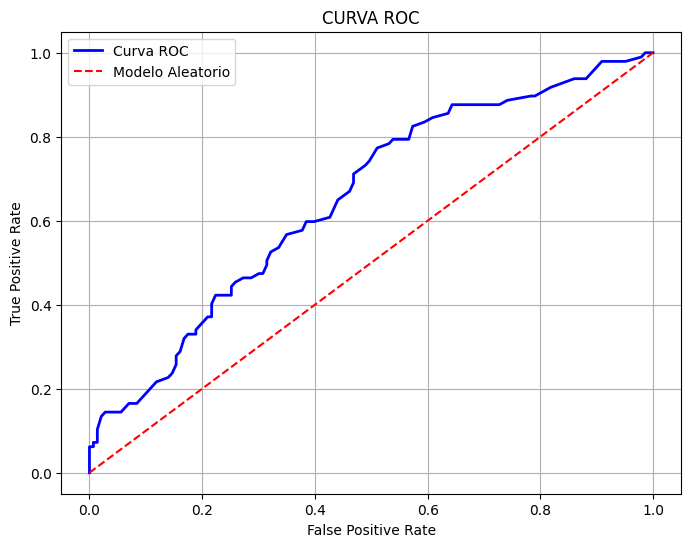

In [6]:
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve


# PROBABILIDADES DEL MODELO

probabilidades = modelo.predict_proba(X_test)[:,1]

# CÁLCULO ROC

fpr, tpr, thresholds = roc_curve(
    y_test,
    probabilidades
)

# GRÁFICA ROC

plt.figure(figsize=(8,6))

# CURVA ROC

plt.plot(
    fpr,
    tpr,
    color='blue',
    linewidth=2,
    label='Curva ROC'
)

# LÍNEA ALEATORIA

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='red',
    label='Modelo Aleatorio'
)

# ETIQUETAS

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("CURVA ROC")

plt.legend()

plt.grid(True)

plt.show()

# AUC
1.0 es perfecto
de otra manera es aleatorio

\=================== VALOR DEL AUC =================

AUC: 0.6520077860284046


<>:26: SyntaxWarning: invalid escape sequence '\='
<>:26: SyntaxWarning: invalid escape sequence '\='
/tmp/ipykernel_33686/2546527967.py:26: SyntaxWarning: invalid escape sequence '\='
  print("\=================== VALOR DEL AUC =================\n")


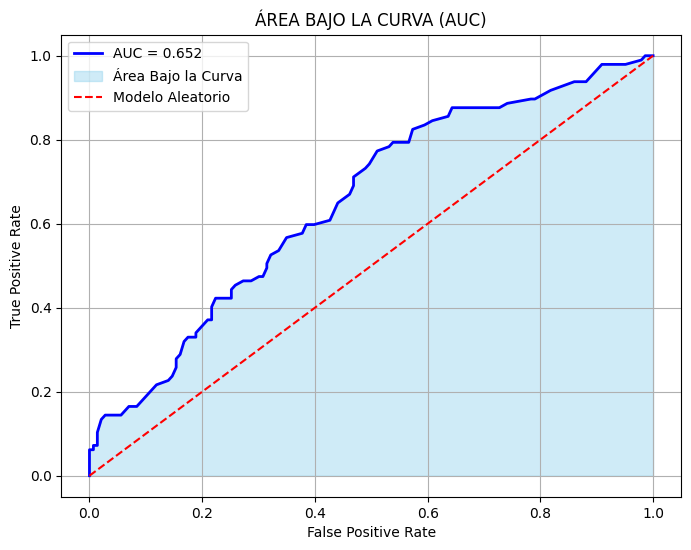


================= INTERPRETACIÓN DEL AUC ========

El modelo tiene aproximadamente un 65.20%
de capacidad para diferenciar correctamente
entre clientes que abandonan y clientes
que permanecen.

Clasificación del modelo: ACEPTABLE


In [7]:
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# PROBABILIDADES

probabilidades = modelo.predict_proba(X_test)[:,1]

# CÁLCULO ROC

fpr, tpr, thresholds = roc_curve(
    y_test,
    probabilidades
)

# CÁLCULO DEL AUC

auc = roc_auc_score(
    y_test,
    probabilidades
)

# MOSTRAR AUC

print("\=================== VALOR DEL AUC =================\n")

print("AUC:", auc)

# GRÁFICA AUC

plt.figure(figsize=(8,6))

# CURVA ROC

plt.plot(
    fpr,
    tpr,
    color='blue',
    linewidth=2,
    label=f'AUC = {auc:.3f}'
)

# ÁREA BAJO LA CURVA

plt.fill_between(
    fpr,
    tpr,
    color='skyblue',
    alpha=0.4,
    label='Área Bajo la Curva'
)

# LÍNEA ALEATORIA

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='red',
    label='Modelo Aleatorio'
)

# ETIQUETAS

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ÁREA BAJO LA CURVA (AUC)")

plt.legend()

plt.grid(True)

plt.show()

# INTERPRETACIÓN

print("\n================= INTERPRETACIÓN DEL AUC ========\n")

print(f"El modelo tiene aproximadamente un {auc*100:.2f}%")

print("de capacidad para diferenciar correctamente")

print("entre clientes que abandonan y clientes")

print("que permanecen.\n")

# CLASIFICACIÓN DEL MODELO

if auc < 0.60:

    print("Clasificación del modelo: BAJO")

elif auc < 0.70:

    print("Clasificación del modelo: ACEPTABLE")

elif auc < 0.80:

    print("Clasificación del modelo: BUENO")

elif auc < 0.90:

    print("Clasificación del modelo: MUY BUENO")

else:

    print("Clasificación del modelo: EXCELENTE")

# 4. Métodos de validación
K-fold cross validation
## * 

In [12]:
from sklearn.model_selection import cross_val_score

import numpy as np

# VALIDACIÓN CRUZADA

scores = cross_val_score(

    modelo,
    X,
    y,
    cv=30

)

# MOSTRAR SCORES INDIVIDUALES

print("\n==============SCORES DE VALIDACIÓN CRUZADA========\n")

for i, score in enumerate(scores, start=1):

    print(f"Iteración {i}: {score:.4f}")

# PROMEDIO GENERAL

promedio = scores.mean()

print("\n================== PROMEDIO GENERAL ===============\n")

print(f"Accuracy Promedio: {promedio:.4f}")

# DESVIACIÓN ESTÁNDAR

desviacion = np.std(scores)

print("\n============== DESVIACIÓN ESTÁNDAR ===============\n")

print(f"Desviación: {desviacion:.4f}")

# INTERPRETACIÓN DE CADA ITERACIÓN

print("\n=========== INTERPRETACIÓN DE LAS ITERACIONES ========\n")

for i, score in enumerate(scores, start=1):

    porcentaje = score * 100

    print(f"Iteración {i}:")

    print(f"El modelo clasificó correctamente")

    print(f"aproximadamente el {porcentaje:.2f}%")

    print("de los registros evaluados.\n")

# INTERPRETACIÓN GENERAL

print("\n======== INTERPRETACIÓN GENERAL DEL MODELO =======\n")

print(f"El modelo obtuvo una precisión promedio")

print(f"de {promedio*100:.2f}%.\n")

# CLASIFICACIÓN DEL RENDIMIENTO

if promedio < 0.60:

    print("Clasificación: RENDIMIENTO BAJO")

elif promedio < 0.70:

    print("Clasificación: RENDIMIENTO ACEPTABLE")

elif promedio < 0.80:

    print("Clasificación: BUEN RENDIMIENTO")

elif promedio < 0.90:

    print("Clasificación: MUY BUEN RENDIMIENTO")

else:

    print("Clasificación: EXCELENTE RENDIMIENTO")

# INTERPRETACIÓN DE ESTABILIDAD


print("\n============ ANÁLISIS DE ESTABILIDAD ===========\n")

if desviacion < 0.02:

    print("El modelo presenta resultados")

    print("muy estables y consistentes.")

elif desviacion < 0.05:

    print("El modelo presenta una")

    print("variabilidad moderada.")

else:

    print("El modelo presenta alta variabilidad")

    print("entre las iteraciones.")


==============SCORES DE VALIDACIÓN CRUZADA========

Iteración 1: 0.6250
Iteración 2: 0.6500
Iteración 3: 0.7500
Iteración 4: 0.6250
Iteración 5: 0.7500
Iteración 6: 0.7000
Iteración 7: 0.6250
Iteración 8: 0.7750
Iteración 9: 0.5750
Iteración 10: 0.6000
Iteración 11: 0.6250
Iteración 12: 0.6250
Iteración 13: 0.6000
Iteración 14: 0.7500
Iteración 15: 0.7750
Iteración 16: 0.5750
Iteración 17: 0.5750
Iteración 18: 0.7000
Iteración 19: 0.6500
Iteración 20: 0.6000
Iteración 21: 0.7250
Iteración 22: 0.6500
Iteración 23: 0.6250
Iteración 24: 0.7000
Iteración 25: 0.7250
Iteración 26: 0.7000
Iteración 27: 0.5250
Iteración 28: 0.6000
Iteración 29: 0.7250
Iteración 30: 0.6250

================== PROMEDIO GENERAL ===============

Accuracy Promedio: 0.6583

============== DESVIACIÓN ESTÁNDAR ===============

Desviación: 0.0666

=========== INTERPRETACIÓN DE LAS ITERACIONES ========

Iteración 1:
El modelo clasificó correctamente
aproximadamente el 62.50%
de los registros evaluados.

Iteración 2:
El

# Validación cruzada estratificada

* Divide en grupos (folds)
* 

In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

import numpy as np

# CONFIGURACIÓN DE StratifiedKFold

skf = StratifiedKFold(

    n_splits=30,
    shuffle=True,
    random_state=42

)

# VALIDACIÓN CRUZADA

scores_estratificados = cross_val_score(

    modelo,
    X,
    y,
    cv=skf

)

print("\n========== SCORES DE VALIDACIÓN CRUZADA ========\n")

for i, score in enumerate(scores_estratificados, start=1):

    print(f"Fold {i}: {score:.4f}")

# PROMEDIO GENERAL

promedio = scores_estratificados.mean()

print("\n================ PROMEDIO GENERAL ==============\n")

print(f"Accuracy Promedio: {promedio:.4f}")

# DESVIACIÓN ESTÁNDAR

desviacion = np.std(scores_estratificados)

print("\n================= DESVIACIÓN ESTÁNDAR =========\n")

print(f"Desviación: {desviacion:.4f}")

# INTERPRETACIÓN DE CADA FOLD

print("\n=============== INTERPRETACIÓN DE LOS FOLDS ========\n")

for i, score in enumerate(scores_estratificados, start=1):

    porcentaje = score * 100

    print(f"Fold {i}:")
    print(f"El modelo clasificó correctamente")
    print(f"aproximadamente el {porcentaje:.2f}%")
    print("de los registros evaluados.\n")

# INTERPRETACIÓN DEL PROMEDIO

print("\n=========== INTERPRETACIÓN GENERAL ============\n")

print(f"El modelo obtuvo una precisión promedio")

print(f"de {promedio*100:.2f}%.\n")

# CLASIFICACIÓN DEL MODELO

if promedio < 0.60:

    print("Clasificación del modelo: BAJO RENDIMIENTO")

elif promedio < 0.70:

    print("Clasificación del modelo: RENDIMIENTO ACEPTABLE")

elif promedio < 0.80:

    print("Clasificación del modelo: BUEN RENDIMIENTO")

elif promedio < 0.90:

    print("Clasificación del modelo: MUY BUEN RENDIMIENTO")

else:

    print("Clasificación del modelo: EXCELENTE RENDIMIENTO")

# INTERPRETACIÓN DE LA DESVIACIÓN

print("\n================ ANÁLISIS DE ESTABILIDAD =========\n")

if desviacion < 0.02:

    print("El modelo es MUY ESTABLE.")

    print("Los resultados son consistentes")

    print("entre las diferentes particiones.")

elif desviacion < 0.05:

    print("El modelo tiene una estabilidad MODERADA.")

    print("Existe una ligera variación")

    print("entre los folds.")

else:

    print("El modelo presenta ALTA VARIABILIDAD.")

    print("El rendimiento cambia considerablemente")

    print("entre las particiones.")


========== SCORES DE VALIDACIÓN CRUZADA ========

Fold 1: 0.6000
Fold 2: 0.6500
Fold 3: 0.7000
Fold 4: 0.6750
Fold 5: 0.7000
Fold 6: 0.6500
Fold 7: 0.5500
Fold 8: 0.5750
Fold 9: 0.7250
Fold 10: 0.7000
Fold 11: 0.6250
Fold 12: 0.6750
Fold 13: 0.6250
Fold 14: 0.7000
Fold 15: 0.6500
Fold 16: 0.6250
Fold 17: 0.6750
Fold 18: 0.6000
Fold 19: 0.6250
Fold 20: 0.6500
Fold 21: 0.6500
Fold 22: 0.6500
Fold 23: 0.6750
Fold 24: 0.7250
Fold 25: 0.7500
Fold 26: 0.7250
Fold 27: 0.7000
Fold 28: 0.7000
Fold 29: 0.6750
Fold 30: 0.7250

================ PROMEDIO GENERAL ==============

Accuracy Promedio: 0.6650

================= DESVIACIÓN ESTÁNDAR =========

Desviación: 0.0473

=============== INTERPRETACIÓN DE LOS FOLDS ========

Fold 1:
El modelo clasificó correctamente
aproximadamente el 60.00%
de los registros evaluados.

Fold 2:
El modelo clasificó correctamente
aproximadamente el 65.00%
de los registros evaluados.

Fold 3:
El modelo clasificó correctamente
aproximadamente el 70.00%
de los registro

# Mecanismo de Validación con un experto
## Juicio de expertos
## W de Kendall

In [18]:
import numpy as np

from scipy.stats import kendalltau

# EVALUACIONES DE LOS EXPERTOS

experto_1 = [4, 5, 3, 4, 5]

experto_2 = [5, 5, 4, 4, 5]

# MOSTRAR DATOS

print("\n============ EVALUACIONES DE LOS EXPERTOS ============\n")

print("Experto 1:", experto_1)

print("Experto 2:", experto_2)

# CÁLCULO DEL COEFICIENTE KENDALL

coeficiente, pvalor = kendalltau(
    experto_1,
    experto_2
)

# MOSTRAR RESULTADOS

print("\n==================== RESULTADOS ESTADÍSTICOS ===========\n")

print(f"Coeficiente Kendall: {coeficiente:.4f}")

print(f"P-Valor: {pvalor:.4f}")

# INTERPRETACIÓN DEL COEFICIENTE

print("\n============== INTERPRETACIÓN DEL COEFICIENTE ==========\n")

if coeficiente == 1:

    print("Existe una concordancia perfecta entre los expertos.")

elif coeficiente >= 0.70:

    print("Existe una concordancia ALTA entre los expertos.")

elif coeficiente >= 0.40:

    print("Existe una concordancia MODERADA entre los expertos.")

elif coeficiente > 0:

    print("Existe una concordancia BAJA entre los expertos.")

elif coeficiente == 0:

    print("No existe relación entre las evaluaciones.")

else:

    print("Existe una relación inversa entre los expertos.")

# INTERPRETACIÓN DEL P-VALOR

print("\n============ INTERPRETACIÓN DEL P-VALOR =============\n")

if pvalor < 0.05:

    print("La relación es ESTADÍSTICAMENTE SIGNIFICATIVA.")

    print("Las evaluaciones muestran evidencia confiable")

    print("de concordancia entre los expertos.")

else:

    print("La relación NO es estadísticamente significativa.")

    print("La concordancia observada podría deberse")

    print("al azar o al tamaño reducido de la muestra.")

# CONCLUSIÓN GENERAL

print("\n================ CONCLUSIÓN GENERAL =============\n")

print(f"El coeficiente Kendall obtenido fue {coeficiente:.4f},")

print("lo que indica el nivel de concordancia entre")

print("las evaluaciones de los expertos.")

print(f"\nEl P-Valor obtenido fue {pvalor:.4f}.")

if pvalor < 0.05:

    print("\nSe concluye que existe una relación")

    print("estadísticamente significativa.")

else:

    print("\nNo existe suficiente evidencia estadística")

    print("para afirmar que la concordancia sea significativa.")


============ EVALUACIONES DE LOS EXPERTOS ============

Experto 1: [4, 5, 3, 4, 5]
Experto 2: [5, 5, 4, 4, 5]

==================== RESULTADOS ESTADÍSTICOS ===========

Coeficiente Kendall: 0.7217
P-Valor: 0.1281

============== INTERPRETACIÓN DEL COEFICIENTE ==========

Existe una concordancia ALTA entre los expertos.

============ INTERPRETACIÓN DEL P-VALOR =============

La relación NO es estadísticamente significativa.
La concordancia observada podría deberse
al azar o al tamaño reducido de la muestra.

================ CONCLUSIÓN GENERAL =============

El coeficiente Kendall obtenido fue 0.7217,
lo que indica el nivel de concordancia entre
las evaluaciones de los expertos.

El P-Valor obtenido fue 0.1281.

No existe suficiente evidencia estadística
para afirmar que la concordancia sea significativa.


# Con 5 expertos

In [19]:
import numpy as np

from scipy.stats import kendalltau

# EVALUACIONES DE LOS EXPERTOS

experto_1 = np.random.randint(1, 6, 5)

experto_2 = np.random.randint(1, 6, 5)

experto_3 = np.random.randint(1, 6, 5)

experto_4 = np.random.randint(1, 6, 5)

experto_5 = np.random.randint(1, 6, 5)

# MOSTRAR DATOS

print("\n============ EVALUACIONES DE LOS EXPERTOS ============\n")

print("Experto 1:", experto_1)

print("Experto 2:", experto_2)

print("Experto 3:", experto_3)

print("Experto 4:", experto_4)

print("Experto 5:", experto_5)

# CÁLCULO DEL COEFICIENTE KENDALL
# (Comparación entre Experto 1 y Experto 2)

coeficiente, pvalor = kendalltau(
    experto_1,
    experto_2
)

# MOSTRAR RESULTADOS

print("\n==================== RESULTADOS ESTADÍSTICOS ===========\n")

print(f"Coeficiente Kendall: {coeficiente:.4f}")

print(f"P-Valor: {pvalor:.4f}")

# INTERPRETACIÓN DEL COEFICIENTE

print("\n============== INTERPRETACIÓN DEL COEFICIENTE ==========\n")

if coeficiente == 1:

    print("Existe una concordancia perfecta entre los expertos.")

elif coeficiente >= 0.70:

    print("Existe una concordancia ALTA entre los expertos.")

elif coeficiente >= 0.40:

    print("Existe una concordancia MODERADA entre los expertos.")

elif coeficiente > 0:

    print("Existe una concordancia BAJA entre los expertos.")

elif coeficiente == 0:

    print("No existe relación entre las evaluaciones.")

else:

    print("Existe una relación inversa entre los expertos.")

# INTERPRETACIÓN DEL P-VALOR

print("\n============ INTERPRETACIÓN DEL P-VALOR =============\n")

if pvalor < 0.05:

    print("La relación es ESTADÍSTICAMENTE SIGNIFICATIVA.")

    print("Las evaluaciones muestran evidencia confiable")

    print("de concordancia entre los expertos.")

else:

    print("La relación NO es estadísticamente significativa.")

    print("La concordancia observada podría deberse")

    print("al azar o al tamaño reducido de la muestra.")

# CONCLUSIÓN GENERAL

print("\n================ CONCLUSIÓN GENERAL =============\n")

print(f"El coeficiente Kendall obtenido fue {coeficiente:.4f},")

print("lo que indica el nivel de concordancia entre")

print("las evaluaciones de los expertos.")

print(f"\nEl P-Valor obtenido fue {pvalor:.4f}.")

if pvalor < 0.05:

    print("\nSe concluye que existe una relación")

    print("estadísticamente significativa.")

else:

    print("\nNo existe suficiente evidencia estadística")

    print("para afirmar que la concordancia sea significativa.")


============ EVALUACIONES DE LOS EXPERTOS ============

Experto 1: [2 4 3 4 1]
Experto 2: [3 4 1 3 3]
Experto 3: [3 5 1 1 5]
Experto 4: [1 3 1 2 5]
Experto 5: [4 4 2 1 2]

==================== RESULTADOS ESTADÍSTICOS ===========

Coeficiente Kendall: 0.2520
P-Valor: 0.5685

============== INTERPRETACIÓN DEL COEFICIENTE ==========

Existe una concordancia BAJA entre los expertos.

============ INTERPRETACIÓN DEL P-VALOR =============

La relación NO es estadísticamente significativa.
La concordancia observada podría deberse
al azar o al tamaño reducido de la muestra.

================ CONCLUSIÓN GENERAL =============

El coeficiente Kendall obtenido fue 0.2520,
lo que indica el nivel de concordancia entre
las evaluaciones de los expertos.

El P-Valor obtenido fue 0.5685.

No existe suficiente evidencia estadística
para afirmar que la concordancia sea significativa.


# 5. Optimización del clasificador
Con ajuste de hiperparámetros
* Busca automáticamente la mejor combinación de parámetros

In [21]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

datos = pd.read_csv(
    "../20260515-viernes/telecom_churn.csv"
)

# PREPROCESAMIENTO

encoder = LabelEncoder()

columnas = [
    "gender",
    "Contract",
    "InternetService"
]

for columna in columnas:

    datos[columna] = encoder.fit_transform(
        datos[columna]
    )

# VARIABLES
X = datos[
    [
        "gender",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "InternetService"
    ]
]

y = datos["Churn"]

# DIVISIÓN DE DATOS

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

print("\nDatos divididos correctamente.")

# PARÁMETROS

parametros = {

    "n_estimators": [50, 100, 200],

    "max_depth": [5, 10, 15],

    "min_samples_split": [2, 5]

}

# GRID SEARCH

grid = GridSearchCV(

    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_grid=parametros,

    cv=5,

    scoring="accuracy"

)

# ENTRENAMIENTO
print("\nEntrenando GridSearchCV...\n")

grid.fit(X_train, y_train)

# RESULTADOS

print("\n============== MEJORES PARÁMETROS =============\n")

print(grid.best_params_)

print("\n=================== MEJOR ACCURACY ============\n")

print(grid.best_score_)


Datos divididos correctamente.

Entrenando GridSearchCV...


============== MEJORES PARÁMETROS =============

{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}

=================== MEJOR ACCURACY ============

0.7072916666666667


# Validación final
## Prueba definitiva usando datos nunca vistos

In [22]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# OBTENER EL MEJOR MODELO

print("\n=========== OBTENIENDO EL MEJOR MODELO ============\n")

mejor_modelo = grid.best_estimator_

print("Mejor modelo recuperado correctamente.\n")

# MOSTRAR PARÁMETROS ÓPTIMOS

print("\n============== PARÁMETROS ÓPTIMOS ===============\n")

print(grid.best_params_)

# REALIZAR PREDICCIONES

print("\========= REALIZANDO PREDICCIONES FINALES ==========\n")

predicciones_finales = mejor_modelo.predict(X_test)

print("Primeras predicciones:\n")

print(predicciones_finales[:10])

# CALCULAR ACCURACY

accuracy_final = accuracy_score(

    y_test,
    predicciones_finales

)

# MOSTRAR ACCURACY

print("\n============ ACCURACY FINAL ================\n")

print(f"Accuracy Final: {accuracy_final:.4f}")

# INTERPRETACIÓN DEL ACCURACY

print("\n=============== INTERPRETACIÓN DEL ACCURACY ========\n")

print(f"El modelo clasificó correctamente")

print(f"aproximadamente el {accuracy_final*100:.2f}%")

print("de los registros evaluados.\n")

print("El Accuracy representa la capacidad")

print("general del modelo para realizar")

print("predicciones correctas.")

# MATRIZ DE CONFUSIÓN

print("\n================== MATRIZ DE CONFUSIÓN =============\n")

matriz = confusion_matrix(
    y_test,
    predicciones_finales
)

print(matriz)

# REPORTE DE CLASIFICACIÓN

print("\n=============== REPORTE DE CLASIFICACIÓN ============\n")

reporte = classification_report(

    y_test,
    predicciones_finales

)

print(reporte)

# CLASIFICACIÓN DEL RENDIMIENTO

print("\n================= CLASIFICACIÓN DEL MODELO ============== \n")

if accuracy_final < 0.60:

    print("Rendimiento del modelo: BAJO")

elif accuracy_final < 0.70:

    print("Rendimiento del modelo: ACEPTABLE")

elif accuracy_final < 0.80:

    print("Rendimiento del modelo: BUENO")

elif accuracy_final < 0.90:

    print("Rendimiento del modelo: MUY BUENO")

else:

    print("Rendimiento del modelo: EXCELENTE")

# INTERPRETACIÓN GENERAL

print("INTERPRETACIÓN GENERAL")

print("================================================\n")

print("El modelo optimizado mediante GridSearchCV")

print("fue evaluado utilizando datos de prueba.")

print("\nLas predicciones finales permiten medir")

print("la capacidad real del algoritmo")

print("para clasificar correctamente")

print("clientes con abandono y clientes estables.")

# =========================================================
# CONCLUSIÓN FINAL
# =========================================================

print("CONCLUSIÓN FINAL\n")

print("La optimización de hiperparámetros permitió")

print("mejorar el desempeño general del modelo.")

print("\nEl Accuracy Final representa")

print("el rendimiento obtenido")

print("sobre datos no utilizados")

print("durante el entrenamiento.")


=========== OBTENIENDO EL MEJOR MODELO ============

Mejor modelo recuperado correctamente.


============== PARÁMETROS ÓPTIMOS ===============

{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
\========= REALIZANDO PREDICCIONES FINALES ==========

Primeras predicciones:

[0 0 0 0 1 1 0 0 0 0]

============ ACCURACY FINAL ================

Accuracy Final: 0.6583

=============== INTERPRETACIÓN DEL ACCURACY ========

El modelo clasificó correctamente
aproximadamente el 65.83%
de los registros evaluados.

El Accuracy representa la capacidad
general del modelo para realizar
predicciones correctas.

================== MATRIZ DE CONFUSIÓN =============

[[113  30]
 [ 52  45]]

=============== REPORTE DE CLASIFICACIÓN ============

              precision    recall  f1-score   support

           0       0.68      0.79      0.73       143
           1       0.60      0.46      0.52        97

    accuracy                           0.66       240
   macro avg       0.64      0.6

<>:21: SyntaxWarning: invalid escape sequence '\='
<>:21: SyntaxWarning: invalid escape sequence '\='
/tmp/ipykernel_33686/3522567563.py:21: SyntaxWarning: invalid escape sequence '\='
  print("\========= REALIZANDO PREDICCIONES FINALES ==========\n")
